### Preparing the Modeling Dataset

We construct the feature matrix (X) and target variable (y) for regression.

The target variable is demand, and predictors include temporal and trip-related features.

Categorical variables are encoded appropriately for regression modeling.

In [1]:
import pandas as pd

DATA_PATH = "../../data/processed/zone_hour_clusters.parquet"

df = pd.read_parquet(DATA_PATH)
df.head()

,zone_id,pickup_hour_ts,demand,avg_fare,avg_distance,hour,day_of_week,is_weekend,day,month,cluster
0,1,2019-01-01 10:00:00,2,61.25,16.90,10,1,0,1,1,3
1,1,2019-01-01 12:00:00,1,135.00,19.30,12,1,0,1,1,3
2,1,2019-01-01 15:00:00,1,106.00,41.28,15,1,0,1,1,3
3,1,2019-01-02 02:00:00,1,30.00,1.27,2,2,0,2,1,1
4,1,2019-01-02 03:00:00,1,15.00,12.65,3,2,0,2,1,1


In [2]:
# Target
y = df["demand"]

# Features
X = df[[
    "hour",
    "day_of_week",
    "is_weekend",
    "avg_fare",
    "avg_distance"
]]

X.head()

,hour,day_of_week,is_weekend,avg_fare,avg_distance
0,10,1,0,61.25,16.90
1,12,1,0,135.00,19.30
2,15,1,0,106.00,41.28
3,2,2,0,30.00,1.27
4,3,2,0,15.00,12.65


### Adding Intercept

A constant term is added to the model to capture baseline demand.

In [3]:
import statsmodels.api as sm

X = sm.add_constant(X)

### Fitting Linear Regression Model

We fit an Ordinary Least Squares (OLS) regression model to estimate the relationship between features and demand.

In [4]:
model = sm.OLS(y, X).fit()

### Model Summary

The regression summary provides coefficient estimates, statistical significance, and overall model fit metrics.

In [5]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 demand   R-squared:                       0.085
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     5483.
Date:                Sun, 22 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:08:05   Log-Likelihood:            -1.8760e+06
No. Observations:              296807   AIC:                         3.752e+06
Df Residuals:                  296801   BIC:                         3.752e+06
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           68.1839      0.742     91.911   

### Model Fit

- **R-squared (0.085)**  
  Indicates that approximately 8.5% of the variability in demand is explained by the model.  
  This relatively low value suggests that important drivers of demand (e.g., location, weather, events) are not yet included.

- **Adjusted R-squared (0.085)**  
  Similar to R-squared but penalizes for additional features. Since both values are nearly identical, the current feature set is small and not overfitting.

---

### Overall Model Significance

- **F-statistic (5483) and Prob(F-statistic) (0.00)**  
  Tests whether the model provides a better fit than a model with no predictors.  
  The extremely low p-value indicates that the model is statistically significant overall.

---

### Coefficients

Each coefficient represents the expected change in demand for a one-unit increase in the predictor, holding all other variables constant.

- **Intercept (const = 68.18)**  
  Baseline demand when all predictors are zero. Mainly serves as a reference point.

- **hour (+3.60)**  
  Demand increases as the day progresses, reflecting increasing activity levels.

- **day_of_week (+2.23)**  
  Suggests a slight increase in demand later in the week, though this variable is encoded numerically and may not fully capture cyclical weekly patterns.

- **is_weekend (-14.28)**  
  Demand is significantly lower on weekends compared to weekdays, indicating the importance of commuting-driven demand.

- **avg_fare (-0.93)**  
  Higher fares are associated with lower demand frequency, likely reflecting that longer or more expensive trips occur less often.

- **avg_distance (-4.37)**  
  Longer trips are less frequent, leading to a negative relationship with demand.

---

### Statistical Significance

- **p-values (P>|t|)**  
  All predictors have p-values close to 0, indicating statistically significant relationships with demand.

However, with a very large dataset, even small effects can become statistically significant. Therefore, practical significance (effect size) should also be considered.

---

### Residual Diagnostics

- **Skew (2.586)**  
  Indicates that demand is right-skewed, with many low values and some extreme high values.

- **Kurtosis (11.658)**  
  Suggests heavy tails and the presence of extreme outliers.

- **Omnibus and Jarque-Bera tests (p ≈ 0)**  
  Indicate that residuals are not normally distributed, violating one of the assumptions of OLS regression.

---

### Autocorrelation

- **Durbin-Watson (0.164)**  
  Indicates strong positive autocorrelation in residuals.  
  This means observations are not independent, which is expected in time-based data such as hourly demand.

---

### Multicollinearity

- **Condition Number (106)**  
  Measures potential multicollinearity between features.  
  This value is not extremely high, but some correlation between variables (e.g., fare and distance) may exist.

### Coefficient Interpretation Table

We extract coefficients into a clean table for easier interpretation.

In [6]:
coef_df = pd.DataFrame({
    "feature": model.params.index,
    "coefficient": model.params.values,
    "p_value": model.pvalues.values
})

coef_df

,feature,coefficient,p_value
0,const,68.183949,0.000000e+00
1,hour,3.598834,0.000000e+00
2,day_of_week,2.226141,6.093811e-28
3,is_weekend,-14.281162,4.321842e-58
4,avg_fare,-0.932309,1.383522e-174
5,avg_distance,-4.373138,0.000000e+00


## Key Takeaways

- The model identifies statistically significant relationships between demand and key features.
- However, explanatory power is limited, indicating missing variables.
- Residual diagnostics suggest violations of OLS assumptions, particularly due to skewness and temporal dependence.
- This model is useful for interpretation, but further improvements are needed for prediction.


# Regression Interpretation 

### Identifying Key Drivers of Demand

To understand which variables have the strongest influence on demand, we compare coefficient magnitudes across predictors.

Since features are not standardized, interpretation focuses on practical effect sizes rather than direct comparison.

In [7]:
coef_df.sort_values(by="coefficient", ascending=False)

,feature,coefficient,p_value
0,const,68.183949,0.000000e+00
1,hour,3.598834,0.000000e+00
2,day_of_week,2.226141,6.093811e-28
4,avg_fare,-0.932309,1.383522e-174
5,avg_distance,-4.373138,0.000000e+00
3,is_weekend,-14.281162,4.321842e-58


### Scenario-Based Interpretation

To better understand model behavior, we interpret coefficients using realistic changes in feature values.

In [9]:
hour_effect = 3.5988 * 5
distance_effect = -4.3731 * 2 

hour_effect, distance_effect

(17.994, -8.7462)

- Increasing time by 5 hours is associated with ~18 additional rides
- Increasing trip distance by 2 units is associated with ~9 fewer rides

### Model Diagnostics and Limitations

We evaluate potential issues affecting model validity and interpretability.

#### Non-linearity

The relationship between demand and time is not linear. Demand typically follows peak patterns (e.g., morning and evening rush hours), which cannot be captured by a simple linear term.

#### Incorrect Encoding of Categorical Variables

The `day_of_week` variable is treated as numeric, implying a linear relationship between days. However, days of the week are categorical and cyclical, and should be encoded accordingly.

#### Omitted Variable Bias

Important predictors such as location, weather, and special events are not included in the model. This can bias coefficient estimates and reduce explanatory power.

#### Autocorrelation

Residuals show strong positive autocorrelation, indicating that observations are not independent. This is expected in time-based data and violates OLS assumptions.

#### Non-Normal Residuals

The demand variable is highly skewed, resulting in non-normal residuals. This affects the reliability of statistical inference.

### Residual Analysis

We analyze residuals to evaluate model assumptions and identify potential issues.

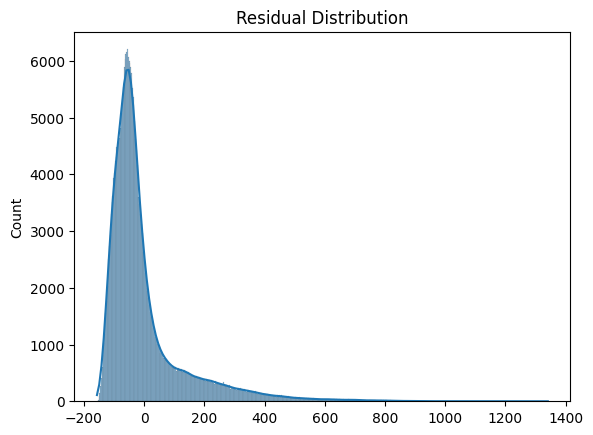

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = model.resid

# Histogram
plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

## Model Interpretation

While the linear regression model provides useful insights into demand drivers, several limitations affect its reliability and predictive power.

Key observations:

- The model captures general trends such as increasing demand throughout the day and differences between weekdays and weekends
- However, the assumption of linear relationships is too restrictive for capturing real-world demand patterns
- Temporal variables are not properly encoded, leading to potential misinterpretation
- Important variables such as location and external factors are missing
- Residual analysis reveals violations of key assumptions, including non-normality and autocorrelation